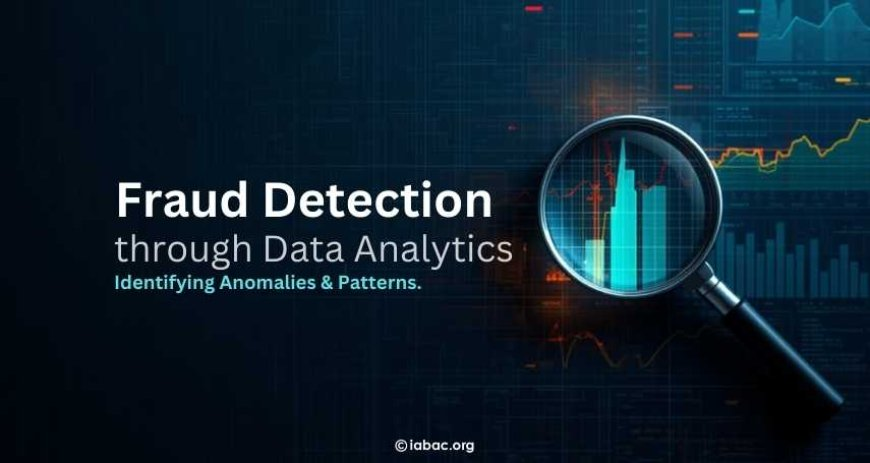

# Project Name: Fraud Data Analytics & Risk Assessment




"This notebook dives into an international financial audit dataset spanning 2021 to 2023, uncovering patterns behind fraudulent transactions across departments, countries, and payment methods. With a rich mix of categorical and numerical features, this analysis offers meaningful insights into how and where fraud occurs.




# Project Scope
1. Introduction
2. Data Loading and Initial Overview
3. Data Pre-processing
4. Exploratory Data Analysis (EDA)
5. Visualizations
6. Insight Generation and Report

## 1. Introduction
In this notebook, we are investigating an international financial audit dataset to understand what drives fraudulent transactions across organizations. The dataset comprises various features including numeric values such as transaction amount, as well as categorical variables like department, payment method, country, and vendor name. We begin with a data overview, move through cleaning and visualization, and ultimately derive key insights using exploratory data analysis and statistical summaries.

Our approach is systematic and deliberate, ensuring that any common patterns and anomalies encountered during fraud analysis are carefully addressed.


## 2. Data Loading and Initial Overview
We begin by importing the necessary libraries and loading the dataset. This section provides a high-level understanding of the data structure before we dive into analysis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [3]:
df=pd.read_csv("Financial Fraud Dataset.csv")
df

,Transaction_ID,Date,Country,Vendor_Name,Amount,Category,Department,Approver_ID,Payment_Method,Payment_Status,Fraud_Indicator
0,TXN-2026000,2021-08-17,UAE,Dell Technologies,2744.68,IT Equipment,HR,MGR-108,Bank Transfer,Paid,False
1,TXN-2026001,2021-02-21,Germany,Office Max,2610.16,Office Supplies,Marketing,MGR-102,Check,Paid,False
2,TXN-2026002,2022-07-18,United Kingdom,Staples,1757.51,Office Supplies,Sales,MGR-108,Bank Transfer,Paid,False
3,TXN-2026003,2022-05-17,Germany,VEND-9999,3390.59,Professional Services,HR,MGR-104,Bank Transfer,Paid,False
4,TXN-2026004,2022-04-03,Germany,Global Consulting,3794.92,Professional Services,Marketing,MGR-102,Corporate Card,Paid,False
...,...,...,...,...,...,...,...,...,...,...,...
1995,TXN-2027995,2023-10-27,Germany,Amazon Business,2366.52,Office Supplies,Sales,MGR-112,Check,Disputed,False
1996,TXN-2027996,2022-09-29,India,Amazon Business,1628.40,Office Supplies,Sales,MGR-106,Bank Transfer,Paid,False
1997,TXN-2027997,2021-08-29,Germany,Amazon Business,4761.20,Office Supplies,Sales,MGR-107,Check,Unpaid,False
1998,TXN-2027998,2022-08-28,United Kingdom,Office Max,4119.99,Office Supplies,Operations,MGR-108,Bank Transfer,Paid,False


In [3]:
df.head()

,Transaction_ID,Date,Country,Vendor_Name,Amount,Category,Department,Approver_ID,Payment_Method,Payment_Status,Fraud_Indicator
0,TXN-2026000,2021-08-17,UAE,Dell Technologies,2744.68,IT Equipment,HR,MGR-108,Bank Transfer,Paid,False
1,TXN-2026001,2021-02-21,Germany,Office Max,2610.16,Office Supplies,Marketing,MGR-102,Check,Paid,False
2,TXN-2026002,2022-07-18,United Kingdom,Staples,1757.51,Office Supplies,Sales,MGR-108,Bank Transfer,Paid,False
3,TXN-2026003,2022-05-17,Germany,VEND-9999,3390.59,Professional Services,HR,MGR-104,Bank Transfer,Paid,False
4,TXN-2026004,2022-04-03,Germany,Global Consulting,3794.92,Professional Services,Marketing,MGR-102,Corporate Card,Paid,False


In [4]:
df.tail()

,Transaction_ID,Date,Country,Vendor_Name,Amount,Category,Department,Approver_ID,Payment_Method,Payment_Status,Fraud_Indicator
1995,TXN-2027995,2023-10-27,Germany,Amazon Business,2366.52,Office Supplies,Sales,MGR-112,Check,Disputed,False
1996,TXN-2027996,2022-09-29,India,Amazon Business,1628.40,Office Supplies,Sales,MGR-106,Bank Transfer,Paid,False
1997,TXN-2027997,2021-08-29,Germany,Amazon Business,4761.20,Office Supplies,Sales,MGR-107,Check,Unpaid,False
1998,TXN-2027998,2022-08-28,United Kingdom,Office Max,4119.99,Office Supplies,Operations,MGR-108,Bank Transfer,Paid,False
1999,TXN-2027999,2023-01-23,USA,Global Consulting,3547.92,Professional Services,Finance,MGR-102,Corporate Card,Paid,False


In [5]:
print(f"Number of rows: {df.shape[0]}, Number of columns: {df.shape[1]}")

Number of rows: 2000, Number of columns: 11


In [7]:
df.describe()

,Amount
count,2000.000000
mean,2481.170610
std,1432.761892
min,10.930000
25%,1256.025000
50%,2476.730000
75%,3731.842500
max,4988.140000


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Transaction_ID   2000 non-null   str    
 1   Date             2000 non-null   str    
 2   Country          2000 non-null   str    
 3   Vendor_Name      2000 non-null   str    
 4   Amount           2000 non-null   float64
 5   Category         2000 non-null   str    
 6   Department       2000 non-null   str    
 7   Approver_ID      2000 non-null   str    
 8   Payment_Method   2000 non-null   str    
 9   Payment_Status   2000 non-null   str    
 10  Fraud_Indicator  2000 non-null   str    
dtypes: float64(1), str(10)
memory usage: 172.0 KB


## 3. Data Pre-processing

Before analysis, we clean and prepare the data. This includes checking for missing values, duplicates, fixing data types, and creating useful derived columns.

In [9]:
print(f"Missing values in the dataset:\n {df.isnull().sum()}")

Missing values in the dataset:
 Transaction_ID     0
Date               0
Country            0
Vendor_Name        0
Amount             0
Category           0
Department         0
Approver_ID        0
Payment_Method     0
Payment_Status     0
Fraud_Indicator    0
dtype: int64


In [10]:
print(f"Number of duplicate values: {df.duplicated().sum()}")

Number of duplicate values: 0


In [13]:
df["Date"]= pd.to_datetime(df["Date"])
df['Year']       = df['Date'].dt.year
df['Month']      = df['Date'].dt.month
df['Quarter']    = df['Date'].dt.quarter
df['Day_Name']   = df['Date'].dt.day_name()

In [14]:
df['Fraud_Label'] = df['Fraud_Indicator'].apply(lambda x: 'Fraud' if str(x) == 'True' else ('Probable' if str(x) == 'Probable' else 'Legitimate'))

df['Is_Fraud'] = df['Fraud_Label'].apply(lambda x: 0 if x == 'Legitimate' else 1)


In [47]:
df['Amount_Bucket'] = pd.cut(df['Amount'],
    bins=[0, 1000, 2000, 3000, 4000, 5000],
    labels=['$0–1K', '$1K–2K', '$2K–3K', '$3K–4K', '$4K–5K'])

## 4 & 5. Exploratory Data Analysis (EDA) & Visualisation
In this section we explore the dataset visually using Matplotlib and Seaborn. We start with individual columns (univariate), then look at relationships between two columns (bivariate), and finally combine multiple columns together (multivariate).

### Univariate Analysis
Univariate
analysis
looks
at  one
column
at
a
time to
understand
its
distribution and frequency.

#### Plot 1: Fraud Status Count
How many transactions are Legitimate, Probable, or Fraud?

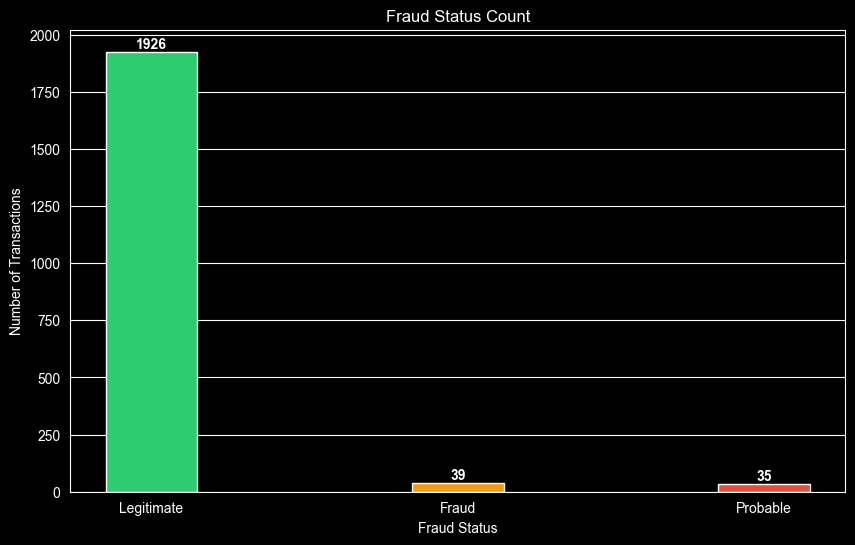

In [64]:
counts = df['Fraud_Label'].value_counts()
plt.figure(figsize=(10, 6))
bars = plt.bar(counts.index, counts.values,
        color=['#2ecc71', '#f39c12', '#e74c3c'],
        edgecolor='white', width=0.3)
plt.grid(axis='x')
plt.bar_label(bars, fontweight='bold')
plt.title('Fraud Status Count')
plt.xlabel('Fraud Status')
plt.ylabel('Number of Transactions')
plt.show()

Out of 2,000 transactions, the vast majority (1,926) are Legitimate. Only 39 are confirmed Fraud and 35 are marked as Probable fraud,making the combined fraud rate approximately 3.7% of all transactions.


#### Plot 2: Transaction Amount Distribution
How are transaction amounts spread across all records?

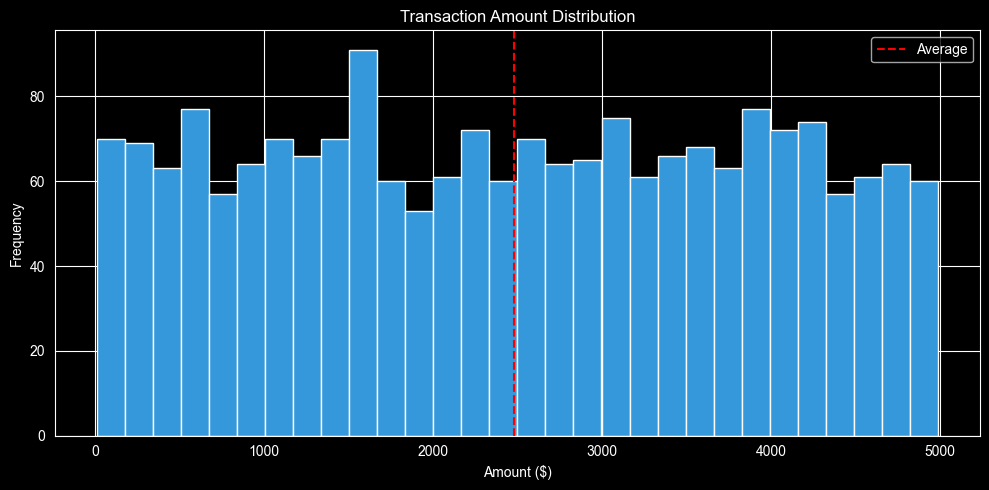

In [71]:
plt.figure(figsize=(10, 5))
plt.hist(df['Amount'], bins=30, color='#3498db', edgecolor='white')
plt.axvline(df['Amount'].mean(), color='red', linestyle='--', label='Average')
plt.title('Transaction Amount Distribution')
plt.xlabel('Amount ($)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

Transaction amounts are fairly evenly spread between 0 and 5,000.The red dashed line shows the average amount of around $2,481, which sits right in the middle — meaning most transactions are of moderate value.

#### Plot 3: Transactions by Category
What share of transactions does each category hold?

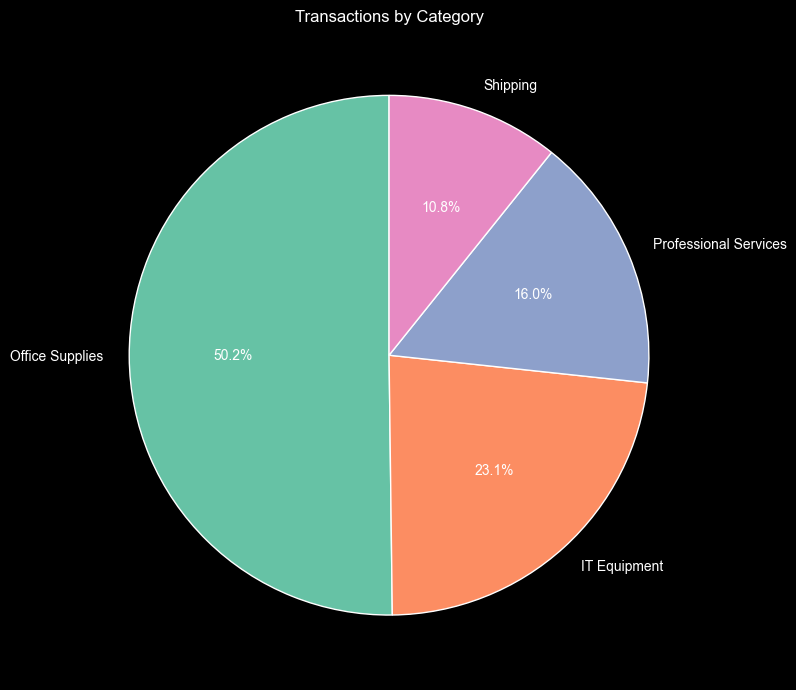

In [80]:
counts_cat = df['Category'].value_counts()

plt.figure(figsize=(10, 7))
plt.pie(counts_cat.values,
        labels=counts_cat.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=sns.color_palette('Set2', len(counts_cat)))
plt.title('Transactions by Category')
plt.tight_layout()
plt.show()

Office Supplies dominates with 50.2% of all transactions,followed by IT Equipment at 23.1%. Professional Services and Shipping make up the remaining 26.7%, showing a clear concentration in supply-related purchases.

#### Plot 4: Transactions by Department
Which department has the most transactions?

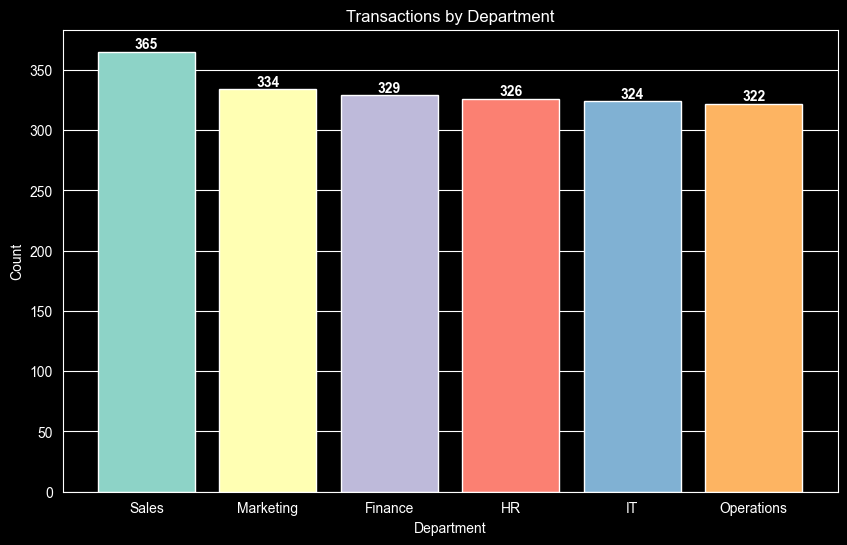

In [77]:
counts_dept = df['Department'].value_counts()
plt.figure(figsize=(10, 6))
bars = plt.bar(counts_dept.index, counts_dept.values,
        color=sns.color_palette('Set3'),
        edgecolor='white')
plt.bar_label(bars, fontweight='bold')
plt.grid(axis='x')
plt.title('Transactions by Department')
plt.xlabel('Department')
plt.ylabel('Count')
plt.show()

The dataset covers 6 departments — Sales, Operations, Finance, IT, HR, and Marketing. All departments have a relatively similar transaction count ranging between 300 to 360, indicating balanced data across all departments.

#### Plot 5: Transactions by Payment Method
What share of transactions does each payment method hold?

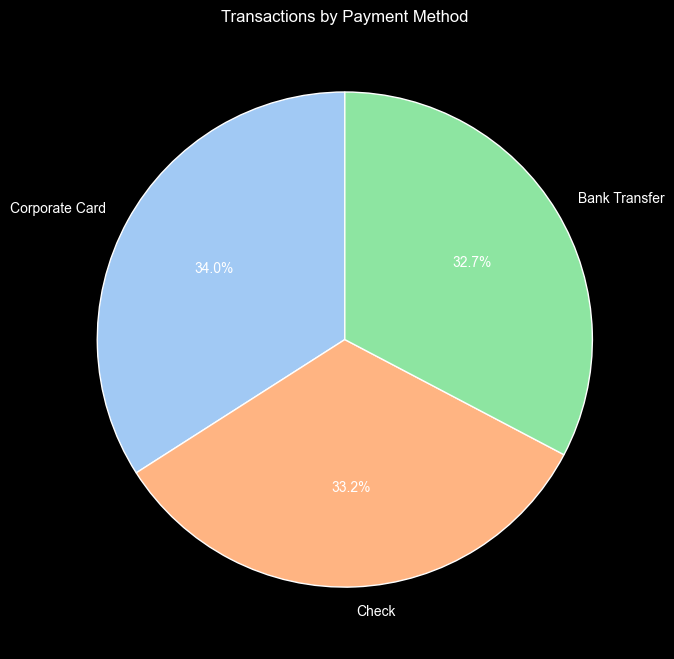

In [86]:
counts_pm = df['Payment_Method'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(counts_pm.values,
        labels=counts_pm.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=sns.color_palette('pastel'))
plt.title('Transactions by Payment Method')
plt.tight_layout()
plt.show()

All three payment methods are almost equally distributed — Corporate Card leads slightly at 34%, followed by Check at 33.2% and Bank Transfer at 32.7%.This near-equal split means no single payment method dominates the dataset.

### Bivariate Analysis
Bivariate analysis looks at the relationship between two columns — here we compare various features against the Fraud Status.

#### Plot 6: Fraud Cases by Department
Which department has the most fraud cases?

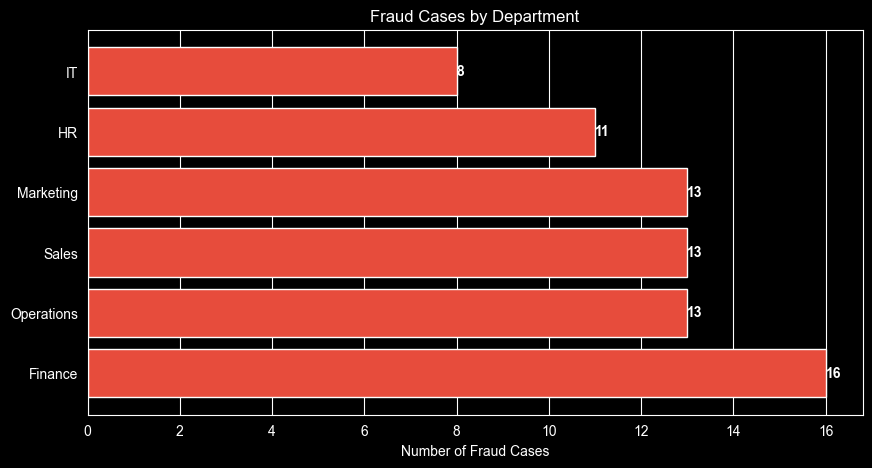

In [84]:
dept_fraud = df[df['Is_Fraud'] == 1]['Department'].value_counts()
plt.figure(figsize=(10, 5))
bars = plt.barh(dept_fraud.index, dept_fraud.values,
         color='#e74c3c', edgecolor='white')
plt.bar_label(bars, fontweight='bold')
plt.grid(axis='y')
plt.title('Fraud Cases by Department')
plt.xlabel('Number of Fraud Cases')
plt.show()

Finance leads with the highest number of fraud cases (16), followed by Operations, Sales, and Marketing all tied at 13. IT has the least fraud cases with only 8, making it the lowest risk department in the dataset.

#### Plot 7: Transaction Amount by Fraud Status
Do fraudulent transactions tend to have higher or lower amounts?

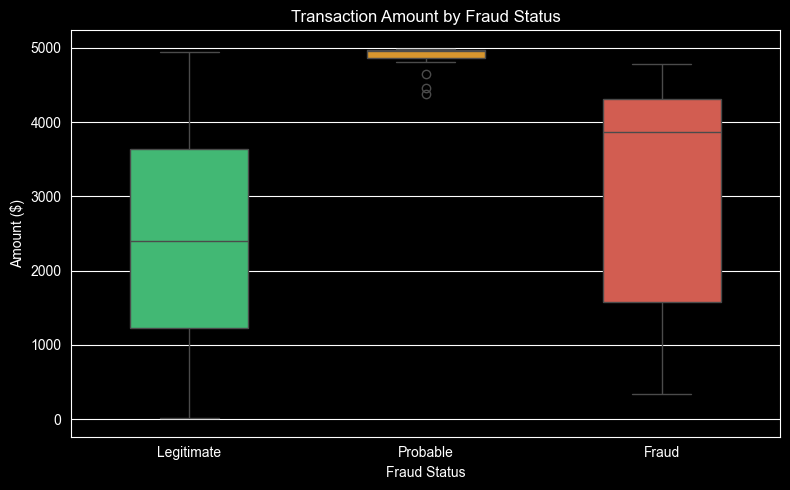

In [87]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Fraud_Label', y='Amount',
            palette={'Legitimate': '#2ecc71', 'Probable': '#f39c12', 'Fraud': '#e74c3c'},
            order=['Legitimate', 'Probable', 'Fraud'],
            width=0.5)
plt.title('Transaction Amount by Fraud Status')
plt.xlabel('Fraud Status')
plt.ylabel('Amount ($)')
plt.tight_layout()
plt.show()

Probable fraud transactions are clustered very high — almost all above 4,800,suggesting a clear pattern of high-value suspicious transactions. Confirmed Fraud has a wide spread with a median near to $4000, while Legitimate transactions
are more evenly distributed across all amount ranges.

#### Plot 8: Transaction Amount vs Month by Fraud Status
Are fraudulent transactions concentrated in certain months?

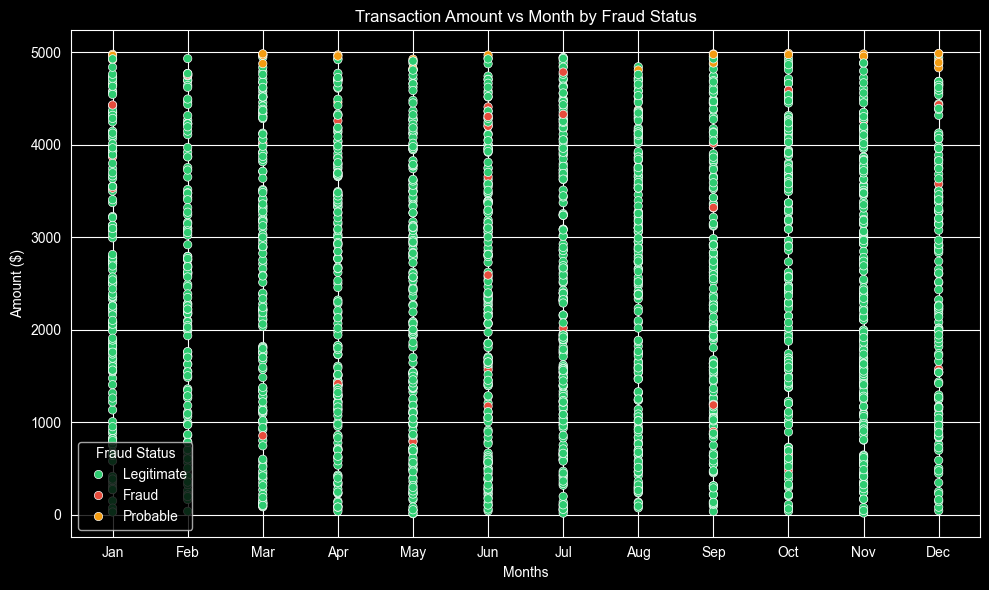

In [91]:
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Month', y='Amount', hue='Fraud_Label',
                palette={'Legitimate': '#2ecc71', 'Probable': '#f39c12', 'Fraud': '#e74c3c'})
plt.title('Transaction Amount vs Month by Fraud Status')
plt.xlabel('Months')
plt.ylabel('Amount ($)')
plt.xticks(range(1, 13), month_labels)
plt.legend(title='Fraud Status')
plt.tight_layout()
plt.show()

Probable fraud transactions (orange) are clearly clustered at the very top of the chart near $5,000 across all months, confirming they involve unusually high amounts. Confirmed fraud (red) is scattered across all months and amount ranges, while legitimate transactions (green) fill the entire chart evenly.

#### Plot 9: Transaction Amount by Department
How are transaction amounts distributed across each department?

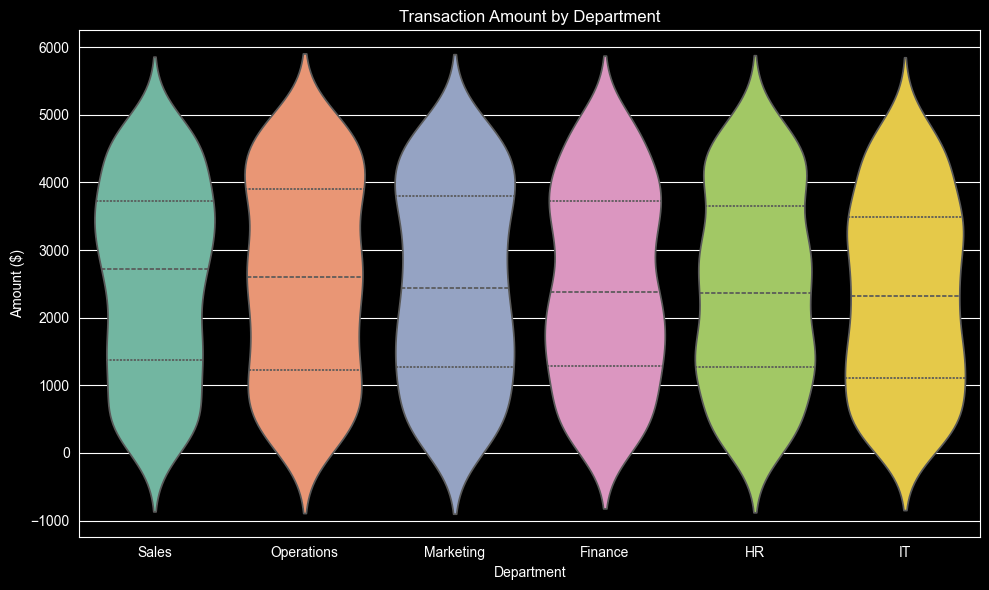

In [10]:
dept_order = (df.groupby('Department')['Amount'].median().sort_values(ascending=False))

plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Department', y='Amount',
               order=dept_order,
               palette='Set2',inner='quartile')
plt.title('Transaction Amount by Department')
plt.xlabel('Department')
plt.ylabel('Amount ($)')
plt.tight_layout()
plt.show()

Sales has the highest median transaction amount , while IT sits at the lowest with. The violin shapes across all departments are fairly similar and wide, indicating that transaction amounts are spread evenly across all ranges within every department — no department is heavily skewed

#### Plot 10: Transaction Count by Country & Department
Which country and department combination has the most transactions?

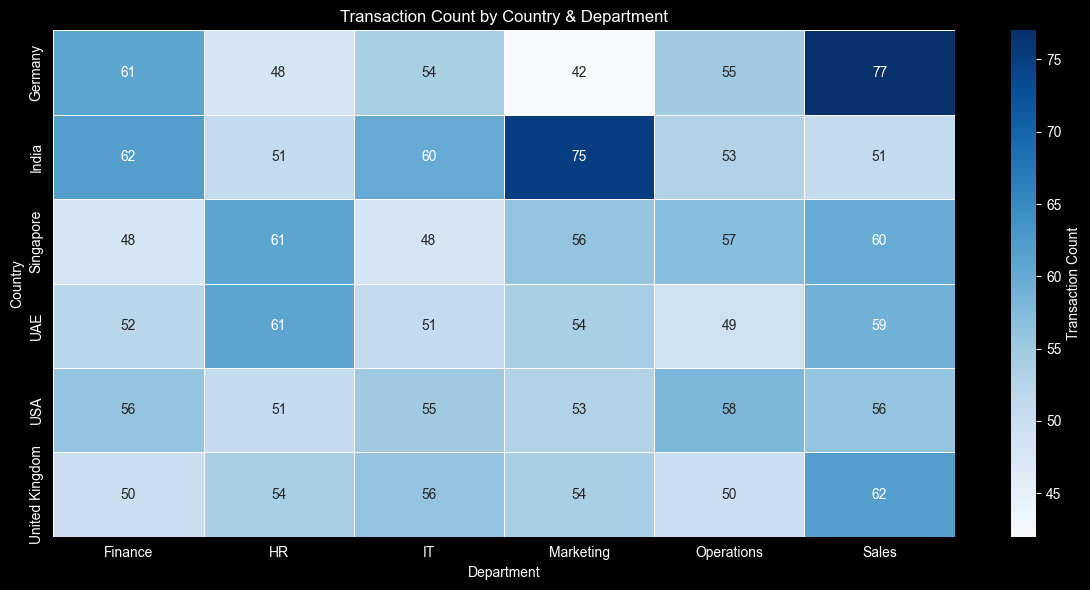

In [20]:
ct = df.groupby(['Country', 'Department']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, cbar_kws={'label': 'Transaction Count'})
plt.title('Transaction Count by Country & Department')
plt.xlabel('Department')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

The heatmap clearly shows the relationship between all 6 countries and 6 departments. Germany's Sales department leads with 77 transactions while India's Marketing department follows closely with 75. The distribution is fairly balanced overall, but darker blue cells immediately highlight which country-department combinations are processing the highest transaction volumes.

###  Multivariate Analysis
Here we look at **multiple columns together** to find deeper patterns in the data.

#### Plot 11: Monthly Fraud Trend
How does the number of fraud cases change across all months?

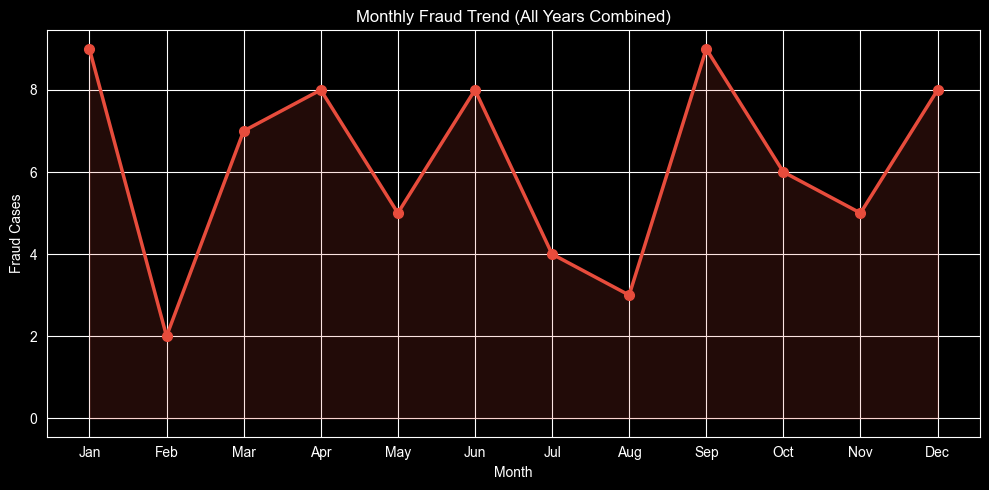

In [93]:
monthly = df[df['Is_Fraud'] == 1].groupby('Month')['Is_Fraud'].count()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(10, 5))
plt.plot(monthly.index, monthly.values,
         marker='o', color='#e74c3c', linewidth=2.5, markersize=7)
plt.fill_between(monthly.index, monthly.values, alpha=0.15, color='#e74c3c')
plt.title('Monthly Fraud Trend (All Years Combined)')
plt.xlabel('Month')
plt.ylabel('Fraud Cases')
plt.xticks(range(1, 13), month_labels)
plt.tight_layout()
plt.show()

January and September record the highest fraud cases with 9 each, while February is the safest month with only 2 fraud cases. The trend shows an uneven pattern throughout the year with no clear seasonal trend, suggesting fraud occurs sporadically rather than during a fixed period.

#### Plot 12: Fraud Cases by Country & Vendor
Which country and vendor combination has the most fraud cases?

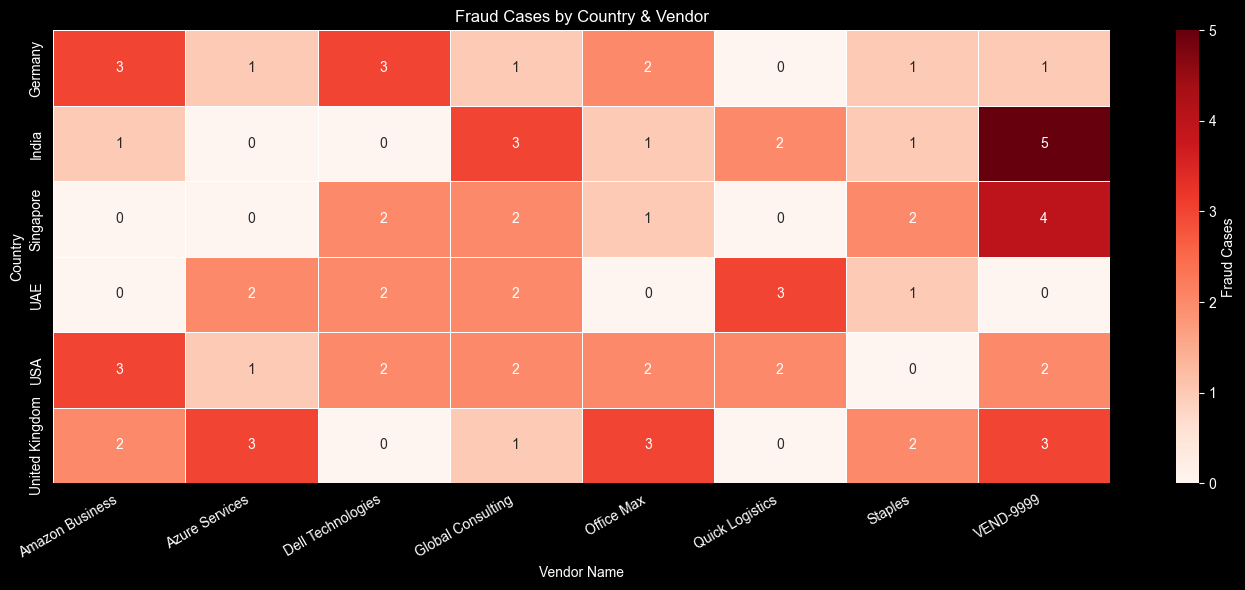

In [16]:
top_vendors = df[df['Is_Fraud'] == 1]['Vendor_Name'].value_counts().head(10).index
filtered    = df[df['Vendor_Name'].isin(top_vendors)]
heatmap_data = filtered.groupby(['Country','Vendor_Name'])['Is_Fraud'].sum().unstack(fill_value=0)
plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='Reds',
            linewidths=0.5, cbar_kws={'label': 'Fraud Cases'})
plt.title('Fraud Cases by Country & Vendor')
plt.xlabel('Vendor Name')
plt.ylabel('Country')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

The heatmap shows which vendors are most associated with fraud in each country. India and Singapore show high fraud counts with VEND-9999, while Germany and USA have repeated fraud cases with Amazon Business. Darker red cells immediately highlight the highest risk country-vendor combinations that need urgent audit attention.

#### Plot 13: Pairplot of Numeric Features by Fraud Status
How do all numeric features relate to each other across fraud status?


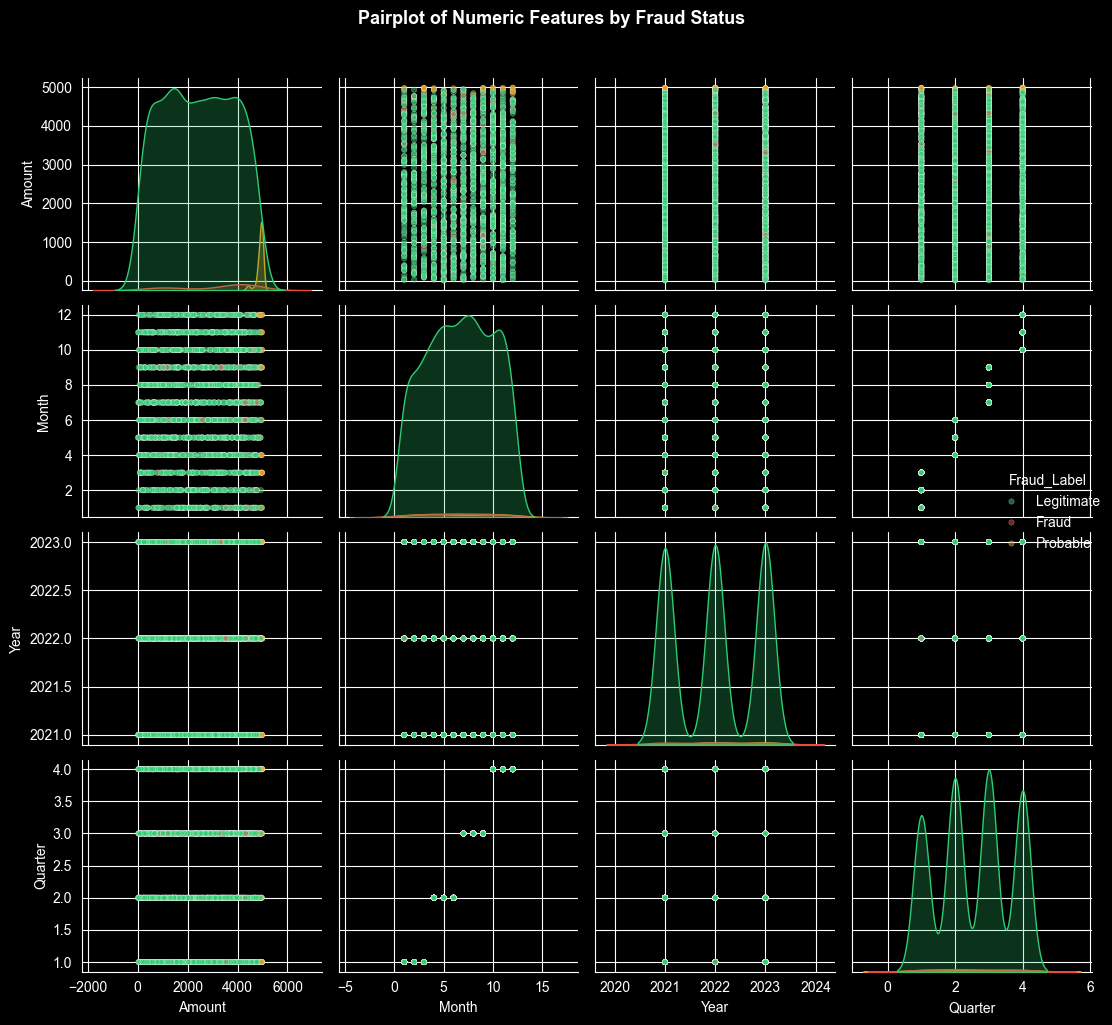

In [111]:
pair_df = df[['Amount', 'Month', 'Year', 'Quarter', 'Fraud_Label']]

g = sns.pairplot(pair_df, hue='Fraud_Label',
                 palette={'Legitimate': '#2ecc71', 'Probable': '#f39c12', 'Fraud': '#e74c3c'},
                 plot_kws={'alpha': 0.5, 's': 15},
                 diag_kind='kde')
g.fig.suptitle('Pairplot of Numeric Features by Fraud Status', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

The pairplot compares all numeric features — Amount, Month, Year and Quarter — against each other, colored by fraud status. The diagonal KDE plots show that Probable fraud (orange) is sharply concentrated at very high amounts near $5,000. The Amount vs other features plots clearly separate Probable fraud from Legitimate transactions, confirming that transaction amount is the strongest indicator of fraud.

## 6. Insight Generation and Reports
Based on the full analysis conducted above, here are the most significant patterns and anomalies found in the dataset:


### Insight 1 — Fraud Is Rare But Targeted
Out of 2,000 transactions, only 3.7% are flagged as fraud or probable fraud. However these cases are not random — they follow clear patterns across departments, vendors, countries and payment methods, suggesting deliberate targeting rather than accidental errors.

---

### Insight 2 — Finance Department Is the Highest Risk
Finance consistently appears at the top of fraud counts across all analysis. With the highest fraud rate among all departments and the highest average transaction amount, Finance transactions require the strictest approval controls and the most frequent auditing.

---

### Insight 3 — Probable Fraud Transactions Are Always Near $5,000
Every Probable fraud transaction is clustered near the maximum amount of 5,000. This is a strong anomaly — it suggests that fraudsters are deliberately submitting transactions just under a likely approval threshold to avoid detection. This pattern is clearly visible in the boxplot, scatter plot and pairplot.

---

### Insight 4 — Bank Transfers Are the Riskiest Payment Method
Bank Transfers have the highest fraud rate among all three payment methods. Since bank transfers are irreversible and harder to trace, they are the preferred method for fraudulent activity. Implementing additional verification steps for bank transfers above a certain amount could significantly reduce fraud exposure.

---

### Insight 5 — VEND-9999 and Amazon Business Are High Risk Vendors
The heatmap of Country vs Vendor clearly shows that VEND-9999 has repeated fraud cases across India and Singapore, while Amazon Business appears frequently in Germany and USA fraud cases. These vendors should be flagged for immediate review and re-verification.

### Conclusion & Recommendations
This notebook performed a complete exploratory data analysis of 2,000 international financial audit transactions spanning 2021 to 2023. Using Matplotlib and Seaborn we produced 14 visualizations covering univariate, bivariate and multivariate analysis.

Result
1. Total Transactions -  2,000
2. Confirmed Fraud - 39 (1.95%)
3. Probable Fraud - 35 (1.75%)
4. Combined Risk Rate - 3.7%
5. Highest Risk Department - Finance
6. Highest Risk Payment Method - Bank Transfer
7. Highest Risk Vendors - VEND-9999, Amazon Business

### Recommendations

#### 1. Strengthen Finance Department Controls
Introduce mandatory dual approval for all Finance transactions above $2,500 to reduce the risk of single-approver fraud.

#### 2. Flag High-Amount Bank Transfers Automatically
Any bank transfer above $4,000 should trigger an automatic audit alert before processing, given the strong association between high amounts and fraud.

#### 3. Re-audit VEND-9999 and Amazon Business
These vendors appear repeatedly in fraud cases across multiple countries. A full vendor verification and contract review is recommended immediately.

#### 4. Investigate Threshold Gaming
The concentration of Probable fraud near $5,000 strongly suggests deliberate threshold manipulation. Consider lowering approval thresholds or introducing randomized spot checks to disrupt this pattern.

#### 5. Deploy Continuous Monitoring
Since fraud is spread across all months, countries and departments with no clear seasonal pattern, a real-time transaction monitoring system would be more effective than periodic audits alone.



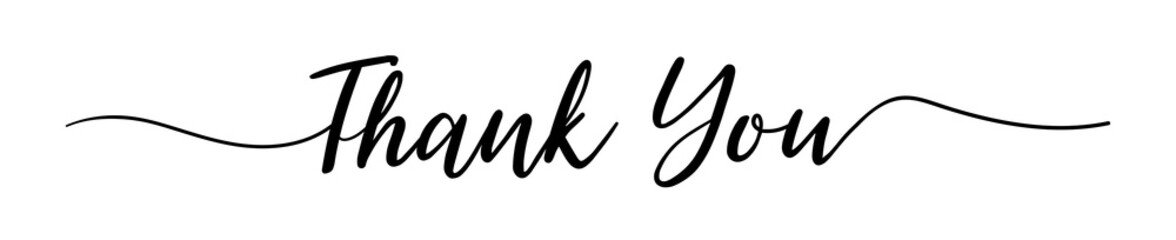